# **Project Name**    -



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **SHOBHIT TYAGI **


# **Project Summary -**

# Project Summary

The restaurant industry generates a vast amount of customer feedback through online reviews and ratings, making it challenging for customers to identify suitable restaurants and for businesses to understand customer preferences. This project aims to analyze restaurant data and customer reviews to uncover meaningful insights and segment restaurants into distinct groups based on their characteristics.

The project utilizes two datasets: a restaurant dataset containing information such as restaurant name, cost, cuisines, collections, and timings, and a reviews dataset containing customer reviews, ratings, reviewer information, and review metadata. Extensive data preprocessing was performed, including handling missing values, cleaning text fields, converting data types, and extracting useful information from reviewer metadata.

Exploratory Data Analysis (EDA) was conducted following the UBM (Univariate, Bivariate, and Multivariate) approach to understand restaurant pricing patterns, rating distributions, cuisine preferences, and relationships among key variables. Customer reviews were further analyzed using the VADER Sentiment Analyzer to generate sentiment scores, providing deeper insights into customer satisfaction beyond traditional ratings.

To enhance the analysis, reviewer influence was incorporated through a weighted sentiment score, giving slightly greater importance to reviews from more active and influential reviewers. Restaurant-level features such as average rating, review count, average sentiment, and weighted sentiment were then created by aggregating multiple reviews for each restaurant.

Finally, machine learning-based clustering techniques were applied to segment restaurants into meaningful groups. Features including cost, ratings, review statistics, sentiment measures, and cuisine indicators were used to identify restaurants with similar characteristics. The resulting clusters provide valuable business insights that can support restaurant recommendations, customer targeting, service improvement strategies, and market analysis.

Overall, the project demonstrates how data analytics, sentiment analysis, and clustering techniques can be combined to transform raw restaurant and review data into actionable business intelligence.


# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Zomato restaurant clustering**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer


### Dataset Loading

In [2]:
dsn = pd.read_csv("Zomato Restaurant names and Metadata.csv")
dsr = pd.read_csv("Zomato Restaurant reviews.csv")

### Dataset First View

In [3]:

print("FIRST 5 ROWS OF THE NAMES DATASET")
display(dsn.head())

print("FIRST 5 ROWS OF THE REVIEWS DATASET")
display(dsr.head())

FIRST 5 ROWS OF THE NAMES DATASET


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


FIRST 5 ROWS OF THE REVIEWS DATASET


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [4]:
print("Rows & Columns count of Dataset 1")
Count=dsn.shape
print("Rows =",Count[0], " Columns =",Count[1])


print("\nRows & Columns count of Dataset 2")
Count=dsr.shape
print("Rows =",Count[0], " Columns =",Count[1])


Rows & Columns count of Dataset 1
Rows = 105  Columns = 6

Rows & Columns count of Dataset 2
Rows = 10000  Columns = 7


### Dataset Information

In [5]:
print("DATASET 1")
print(f"Dataset Columns: {', '.join(dsn.columns)}\n")

print("DATASET 2")
print(f"Dataset Columns: {', '.join(dsr.columns)}")

DATASET 1
Dataset Columns: Name, Links, Cost, Collections, Cuisines, Timings

DATASET 2
Dataset Columns: Restaurant, Reviewer, Review, Rating, Metadata, Time, Pictures



#### Duplicate Values

In [6]:
duplicate_count = dsn.duplicated().sum()
print(f"Total Duplicate Recordsin Dataset 1 : {duplicate_count}")

duplicate_count1 = dsr.duplicated().sum()
print(f"Total Duplicate Recordsin Dataset 2 : {duplicate_count1}")

Total Duplicate Recordsin Dataset 1 : 0
Total Duplicate Recordsin Dataset 2 : 36


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
print("DATASET 1")
missing_values = dsn.isnull().sum()
for column, count in missing_values.items():
    print(f"{column} : {count}")

print("\nDATASET 2")
missing_values = dsr.isnull().sum()
for column, count in missing_values.items():
    print(f"{column} : {count}")

DATASET 1
Name : 0
Links : 0
Cost : 0
Collections : 54
Cuisines : 0
Timings : 1

DATASET 2
Restaurant : 0
Reviewer : 38
Review : 45
Rating : 38
Metadata : 38
Time : 38
Pictures : 0


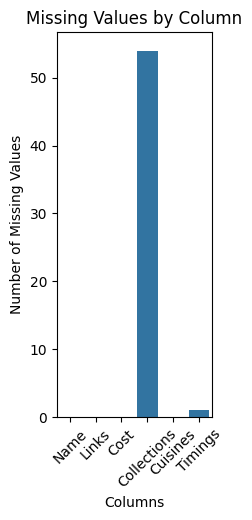

In [8]:
# Visualizing the missing values

import matplotlib.pyplot as plt
import seaborn as sns

missing_values = dsn.isnull().sum()

# Plot
plt.figure(figsize=(2, 5))
sns.barplot(x=missing_values.index, y=missing_values.values)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [9]:
print("DATASET 1")
print(f"Dataset Columns: {', '.join(dsn.columns)}\n")

print("DATASET 2")
print(f"Dataset Columns: {', '.join(dsr.columns)}")

DATASET 1
Dataset Columns: Name, Links, Cost, Collections, Cuisines, Timings

DATASET 2
Dataset Columns: Restaurant, Reviewer, Review, Rating, Metadata, Time, Pictures


### Variables Description

Dataset 1: Restaurant Information Dataset

This dataset contains detailed information about restaurants listed on the platform. It includes restaurant names, website links, average cost, collection categories, cuisines offered, and operating timings. The dataset helps in understanding restaurant characteristics, pricing patterns, cuisine distribution, and service availability.

Columns:

Name – Name of the restaurant.
Links – Restaurant's Zomato webpage link.
Cost – Average cost for two people.
Collections – Restaurant category or collection.
Cuisines – Types of cuisines offered.
Timings – Opening and closing hours of the restaurant.


Dataset 2: Customer Reviews Dataset

This dataset contains customer-generated reviews and ratings for restaurants. It provides valuable insights into customer experiences, opinions, and satisfaction levels. The dataset was used for rating analysis, sentiment analysis, and reviewer influence analysis.

Columns:

Restaurant – Name of the reviewed restaurant.
Reviewer – Name of the reviewer.
Review – Customer review text.
Rating – Rating given by the customer.
Metadata – Reviewer's review count and follower count.
Time – Date and time when the review was posted.
Pictures – Number of pictures uploaded with the review.

### Check Unique Values for each variable.

In [130]:
# Check Unique Values for each variable.
print ("NAME    COUNT")
for col in dsn.columns:
    print(f"{col}    {dsn[col].nunique()}")


print ("\nNAME    COUNT")
for col in dsr.columns:
    print(f"{col}    {dsr[col].nunique()}")

NAME    COUNT
Name    105
Links    105
Cost    29
Collections    42
Cuisines    92
Timings    77

NAME    COUNT
Restaurant    100
Reviewer    7446
Review    9364
Rating    10
Metadata    2477
Time    9782
Pictures    36


## 3. ***Data Wrangling***

### Data Wrangling Code

In [23]:
reviews = dsr.copy()
restaurants = dsn.copy()
restaurants.drop_duplicates(inplace=True)

#Filled the missing values 
restaurants["Collections"] = (
    restaurants["Collections"]
    .fillna("Not Specified")
)

restaurants["Timings"] = (
    restaurants["Timings"]
    .fillna("Not Available")
)

# Remove unwanted space 
restaurants["Name"] = restaurants["Name"].str.strip()
restaurants["Cuisines"] = restaurants["Cuisines"].str.strip()

#convert the cost type from object to int
restaurants["Cost"] = restaurants["Cost"].str.replace(",", "", regex=False)
restaurants["Cost"] = pd.to_numeric(restaurants["Cost"])
print("Updated cost type = ",restaurants["Cost"].dtype)

#segregate reviews count and followers from metadata 
reviews["Reviewer_Reviews"] = (
    reviews["Metadata"]
    .str.extract(r'(\d+)\s*Review')
    .astype(float)
)

reviews["Followers"] = (
    reviews["Metadata"]
    .str.extract(r'(\d+)\s*Followers')
    .astype(float)
)

# Fill missing values
reviews["Reviewer_Reviews"] = reviews["Reviewer_Reviews"].fillna(0)
reviews["Followers"] = reviews["Followers"].fillna(0)

#Converting rating to numeric 
reviews["Rating"] = pd.to_numeric(
    reviews["Rating"],
    errors="coerce"
)

#Converting rating into Avg rating
restaurant_ratings = (
    reviews.groupby("Restaurant")
    .agg(
        Avg_Rating=("Rating", "mean"),
        Review_Count=("Rating", "count")
    )
    .reset_index()
)

#Merging avg rating with Dataset 1
restaurant_eda = pd.merge(
    restaurants,
    restaurant_ratings,
    left_on="Name",
    right_on="Restaurant",
    how="left"
)

restaurant_eda.drop(columns=["Restaurant"], inplace=True)


Updated cost type =  int64


In [24]:
restaurant_eda.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Avg_Rating,Review_Count
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",4.28,100.0
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,4.70,100.0
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",4.66,100.0
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,3.21,100.0
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",4.34,100.0


### What all manipulations have you done and insights you found?

Removed duplicate restaurant records to improve data quality.
Handled missing values without losing important observations.
Standardized textual information for consistency.
Converted cost and rating fields into numerical formats suitable for analysis.
Extracted reviewer engagement metrics from unstructured metadata.
Generated restaurant-level performance indicators such as average rating and review count.
Created a consolidated dataset ready for exploratory data analysis, sentiment analysis, clustering, and machine learning applications.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

<Axes: xlabel='Cost', ylabel='Count'>

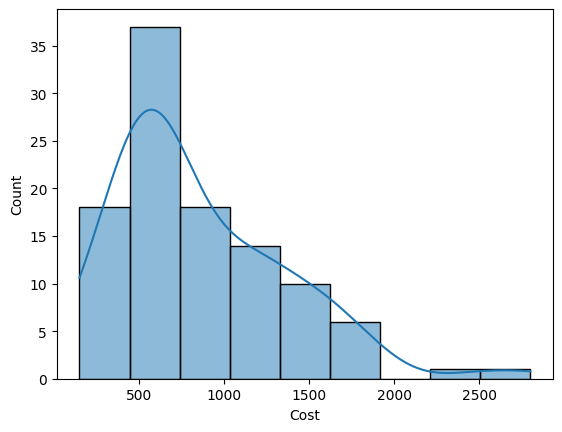

In [25]:
sns.histplot(restaurants["Cost"], kde=True)

##### 1. Why did you pick the specific chart?

Histogram helped in understand the pricing distribution of the restraunts

##### 2. What is/are the insight(s) found from the chart?

We can conclude that most of the hotels range between 300-1000 cost range

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This shows the dominant segment of market 

#### Chart - 2

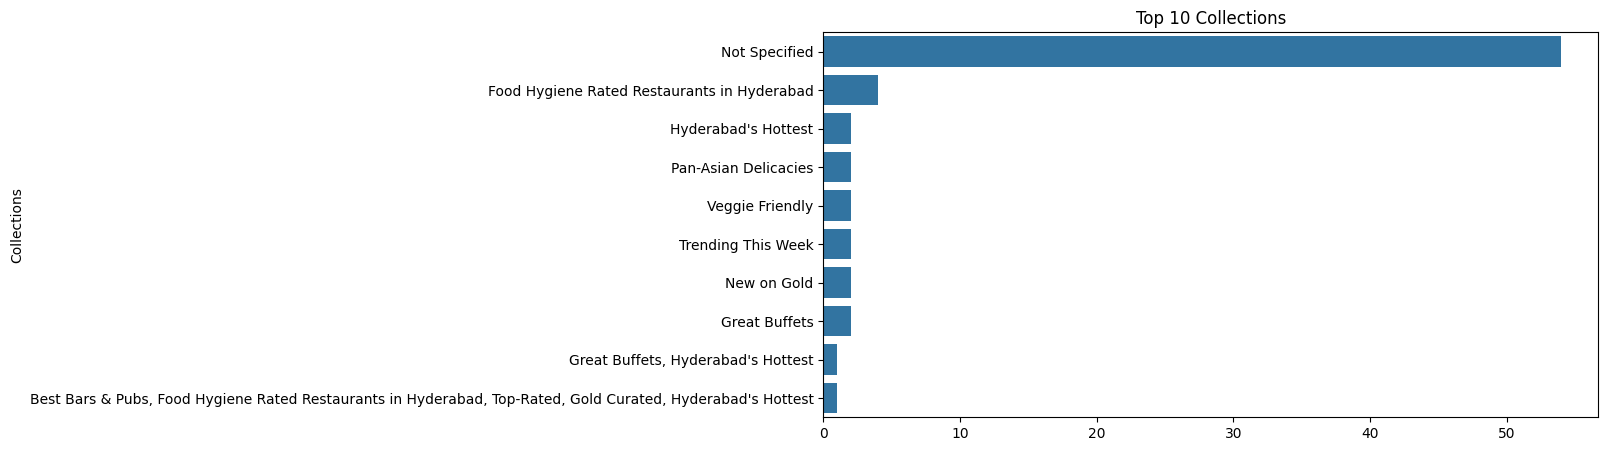

In [26]:
top_collections = (
    restaurants["Collections"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_collections.values,
    y=top_collections.index
)

plt.title("Top 10 Collections")
plt.show()

##### 1. Why did you pick the specific chart?

 A bar chart can easliy compare categories with their frequency.

##### 2. What is/are the insight(s) found from the chart?

Most of the collections are not specified

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

No the collection data is not enough to provide and insight

#### Chart - 3

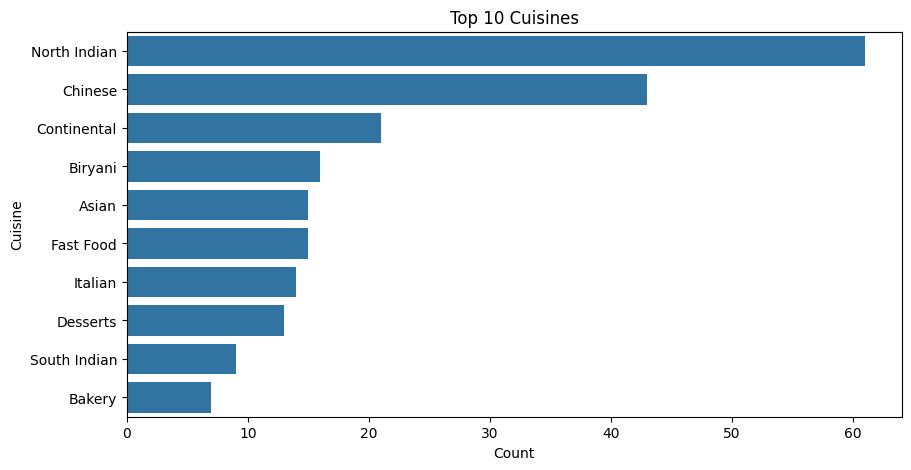

In [27]:
from collections import Counter

cuisine_list = []

for row in restaurants["Cuisines"].dropna():
    cuisine_list.extend(
        [c.strip() for c in row.split(",")]
    )

top_cuisines = pd.DataFrame(
    Counter(cuisine_list).most_common(10),
    columns=["Cuisine","Count"]
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_cuisines,
    x="Count",
    y="Cuisine"
)

plt.title("Top 10 Cuisines")
plt.show()

##### 1. Why did you pick the specific chart?

Easily compare frequency of diffrent categories 

##### 2. What is/are the insight(s) found from the chart?

These are the top 10 cuisine from which we can conclude that Most of the restraunt have North indian cuisine

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This help in identifing dominant cuisines and weak cuisine avilable in restraunts.

#### Chart - 4

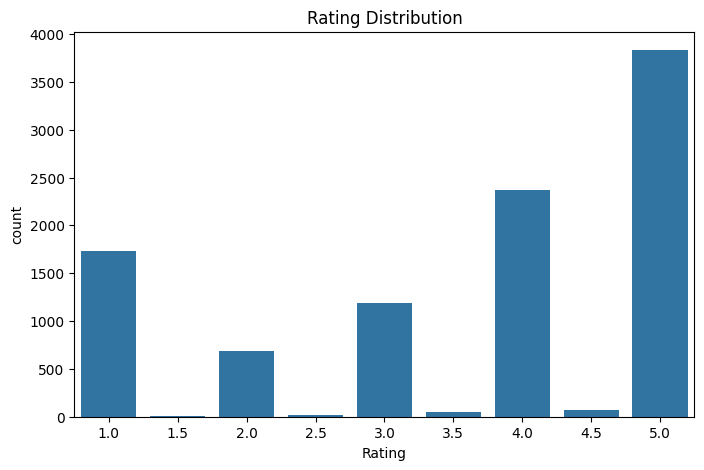

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=reviews,
    x="Rating"
)

plt.title("Rating Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Count plot is used to show frequency of each rating category

##### 2. What is/are the insight(s) found from the chart?

We can say most of the reviews are 5 stars and 4 stars but there are more than 15% 1 star rating

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes with the help of this chart we can segregate top rated restraunt and understand which restraunts require imporvement

#### Chart - 5

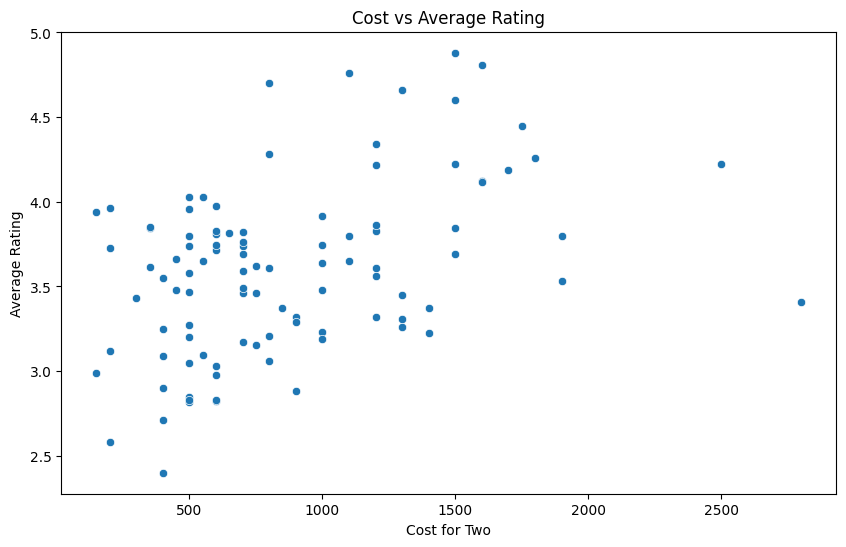

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=restaurant_eda,
    x="Cost",
    y="Avg_Rating"
)

plt.title("Cost vs Average Rating")
plt.xlabel("Cost for Two")
plt.ylabel("Average Rating")

plt.show()

##### 1. Why did you pick the specific chart?

Sctter plot is used to understand the relationships between two numerical variables

##### 2. What is/are the insight(s) found from the chart?

Restraunts costing less than 1000 are only rated  upto 4 stars and restraunt betweens 1000-2000 have an avg rating between 3.5-5 stars 

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This help in understanding the cost to satifaction ratio we can conclude that restraunt costing more than 1500 have low cost to satisfaction ratio

#### Chart - 6

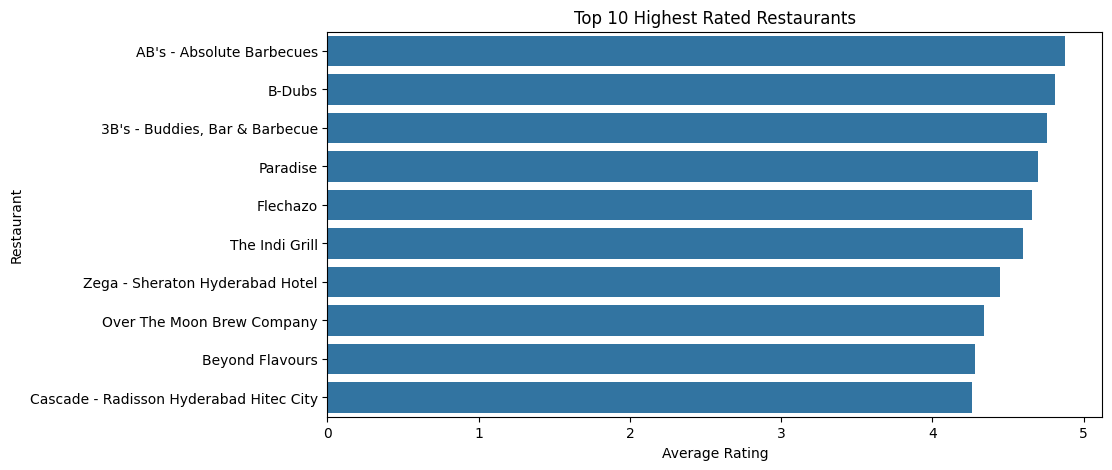

In [31]:
top_rated = (
    restaurant_eda
    .sort_values("Avg_Rating", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_rated,
    x="Avg_Rating",
    y="Name"
)

plt.title("Top 10 Highest Rated Restaurants")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant")

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for comparing average ratings across a small set of restaurants and ranking them.

##### 2. What is/are the insight(s) found from the chart?

we can identify the highest-rated restaurants according to customer reviews

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Help zomato feature highly rated restaurants in recommendations.

#### Chart - 7

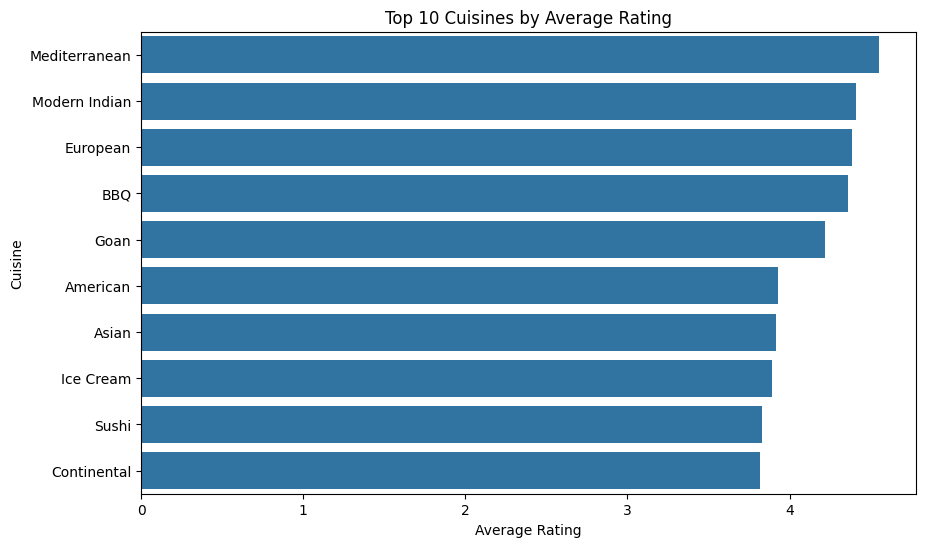

In [38]:
cuisine_rating = restaurant_eda.copy()

cuisine_rating["Cuisine"] = (
    cuisine_rating["Cuisines"]
    .str.split(",")
)

cuisine_rating = cuisine_rating.explode("Cuisine")

cuisine_rating["Cuisine"] = (
    cuisine_rating["Cuisine"]
    .str.strip()
)

avg_cuisine_rating = (
    cuisine_rating.groupby("Cuisine")["Avg_Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=avg_cuisine_rating,
    x="Avg_Rating",
    y="Cuisine"
)

plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is the best choice for comparing ratings across multiple cuisine categories.

##### 2. What is/are the insight(s) found from the chart?

Meiterranean and moder india is the highest rated cuisine

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants can prioritize highly-rated cuisines in menu planning.

#### Chart - 8

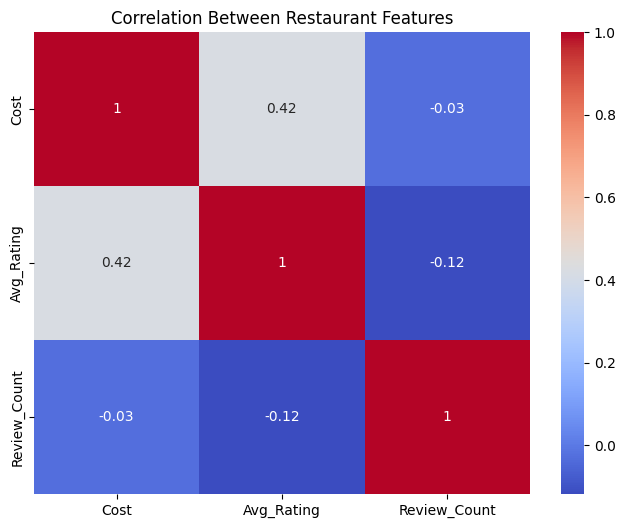

In [39]:
corr_df = restaurant_eda[
    ["Cost", "Avg_Rating", "Review_Count"]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Restaurant Features")
plt.show()

##### 1. Why did you pick the specific chart?

Corelation heatmap is used to show relation between variables

##### 2. What is/are the insight(s) found from the chart?

As restaurant cost increases, ratings tend to increase moderately customers generally rate premium restaurants slightly better.Review-count is not releated to cost

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Higher-priced restaurants often provide better ambiance, service, or food quality However, the relationship is not very strong, meaning expensive restaurants are not guaranteed to receive high ratings.

#### Chart - 9

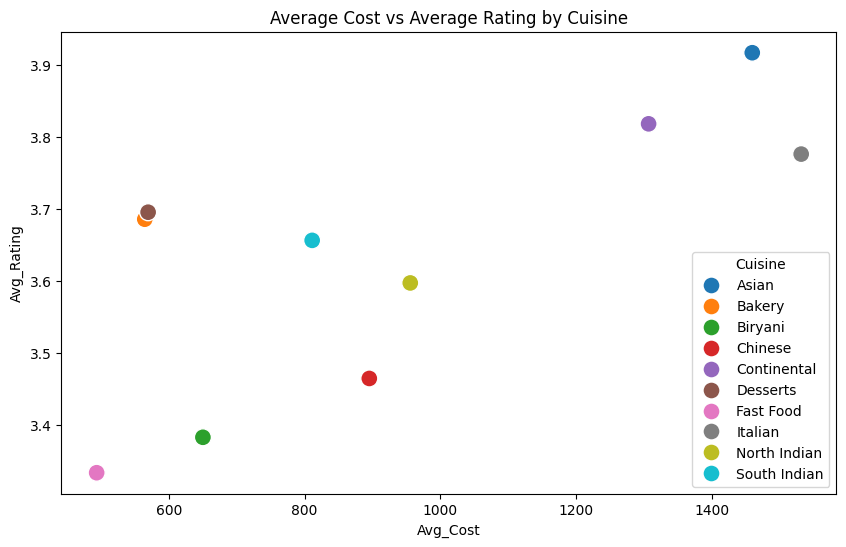

In [40]:
avg_cuisine_stats = (
    cuisine_rating.groupby("Cuisine")
    .agg(
        Avg_Cost=("Cost", "mean"),
        Avg_Rating=("Avg_Rating", "mean")
    )
    .reset_index()
)

top_cuisines = (
    cuisine_rating["Cuisine"]
    .value_counts()
    .head(10)
    .index
)

avg_cuisine_stats = avg_cuisine_stats[
    avg_cuisine_stats["Cuisine"].isin(top_cuisines)
]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=avg_cuisine_stats,
    x="Avg_Cost",
    y="Avg_Rating",
    hue="Cuisine",
    s=150
)

plt.title("Average Cost vs Average Rating by Cuisine")
plt.show()

##### 1. Why did you pick the specific chart?

This scatter plot allows us to simultaneously analyze Average cost of each cuisine Average customer rating of each cuisine
Differences between cuisine categories

##### 2. What is/are the insight(s) found from the chart?

Asian, Italian, and Continental cuisines appear to be premium yet well-received categories.Bakery and Desserts offer excellent customer satisfaction at lower prices

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants can use this information when deciding cuisine offerings and pricing strategies

## ***6. Feature Engineering & Data Pre-processing***

### 1. Sentiment analysis

In [36]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()
reviews["Sentiment_Score"] = reviews["Review"].astype(str).apply(
    lambda review: sia.polarity_scores(review)["compound"]
)

def get_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

reviews["Sentiment"] = reviews["Sentiment_Score"].apply(get_sentiment)

reviews.to_csv("Reviews with sentiment score.csv", index=False)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\stsho\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [42]:
reviews["Influence_Score"] = (
    np.log1p(reviews["Followers"]) +
    np.log1p(reviews["Reviewer_Reviews"])
)

weighted_sentiment = (
    reviews.groupby("Restaurant")
    .apply(
        lambda x: np.average(
            x["Sentiment_Score"],
            weights=x["Influence_Score"]
        )
    )
    .reset_index(name="Weighted_Sentiment")
)

avg_sentiment = (
    reviews.groupby("Restaurant")["Sentiment_Score"]
    .mean()
    .reset_index(name="Avg_Sentiment")
)
Final_reviews = (
    avg_sentiment
    .merge(weighted_sentiment, on="Restaurant")
)

C:\Users\stsho\AppData\Local\Temp\ipykernel_8928\1495916426.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [43]:
Final_reviews.head()

,Restaurant,Avg_Sentiment,Weighted_Sentiment
0,10 Downing Street,0.659678,0.768950
1,13 Dhaba,0.366539,0.547975
2,"3B's - Buddies, Bar & Barbecue",0.810532,0.800833
3,AB's - Absolute Barbecues,0.902735,0.913281
4,Absolute Sizzlers,0.489637,0.413165


In [44]:
restaurant_eda = pd.merge(
    restaurant_eda,
    Final_reviews,
    left_on="Name",
    right_on="Restaurant",
    how="left"
)

restaurant_eda.drop(columns=["Restaurant"], inplace=True)



restaurant_eda.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Avg_Rating,Review_Count,Avg_Sentiment,Weighted_Sentiment
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",4.28,100.0,0.663394,0.638920
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,4.70,100.0,0.827125,0.802824
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",4.66,100.0,0.790563,0.770101
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,3.21,100.0,0.288774,0.422792
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",4.34,100.0,0.777797,0.786692


In [45]:
print("Restraunt with no reviews",restaurant_eda.isnull().sum())

restaurant_eda[
    restaurant_eda["Avg_Rating"].isnull()
][["Name", "Cost", "Cuisines"]]

Restraunt with no reviews Name                  0
Links                 0
Cost                  0
Collections           0
Cuisines              0
Timings               0
Avg_Rating            5
Review_Count          5
Avg_Sentiment         5
Weighted_Sentiment    5
dtype: int64


,Name,Cost,Cuisines
100,IndiBlaze,600,"Fast Food, Salad"
101,Sweet Basket,200,"Bakery, Mithai"
102,Angaara Counts 3,500,"North Indian, Biryani, Chinese"
103,Wich Please,250,Fast Food
104,Republic Of Noodles - Lemon Tree Hotel,1700,"Thai, Asian, Chinese, Malaysian"


In [151]:
# FILLING THE MISSING VALUES WITH MEDIAN SO AS TO CREATE A NUETRAL RATING 

restaurant_eda["Review_Count"] = (
    restaurant_eda["Review_Count"]
    .fillna(0)
)

restaurant_eda["Avg_Rating"] = (
    restaurant_eda["Avg_Rating"]
    .fillna(restaurant_eda["Avg_Rating"].median())
)

restaurant_eda["Avg_Sentiment"] = (
    restaurant_eda["Avg_Sentiment"]
    .fillna(restaurant_eda["Avg_Sentiment"].median())
)

restaurant_eda["Weighted_Sentiment"] = (
    restaurant_eda["Weighted_Sentiment"]
    .fillna(restaurant_eda["Weighted_Sentiment"].median())
)

In [152]:
#SEPERATING CUISINES FOR CLUSTERING

top_cuisines = (
    cuisine_rating["Cuisine"]
    .value_counts()
    .head(10)
    .index
)

print(top_cuisines)

for cuisine in top_cuisines:
    restaurant_eda[f"Cuisine_{cuisine}"] = (
        restaurant_eda["Cuisines"]
        .str.contains(cuisine, case=False, na=False)
        .astype(int)
    )


Index(['North Indian', 'Chinese', 'Continental', 'Biryani', 'Asian',
       'Fast Food', 'Italian', 'Desserts', 'South Indian', 'Bakery'],
      dtype='object', name='Cuisine')


In [153]:
restaurant_eda.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Avg_Rating,Review_Count,Avg_Sentiment,Weighted_Sentiment,Cuisine_North Indian,Cuisine_Chinese,Cuisine_Continental,Cuisine_Biryani,Cuisine_Asian,Cuisine_Fast Food,Cuisine_Italian,Cuisine_Desserts,Cuisine_South Indian,Cuisine_Bakery
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",4.28,100.0,0.663394,0.638920,1,1,1,0,0,0,0,0,1,0
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,4.70,100.0,0.827125,0.802824,1,1,0,1,0,0,0,0,0,0
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",4.66,100.0,0.790563,0.770101,1,0,0,0,1,0,0,1,0,0
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,3.21,100.0,0.288774,0.422792,1,1,0,1,0,0,0,0,0,0
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",4.34,100.0,0.777797,0.786692,1,1,1,0,1,0,0,0,0,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

### Missing Value Imputation Techniques

Several missing value imputation techniques were applied during data preprocessing to ensure data completeness while preserving as much information as possible. For categorical attributes such as **Collections** and **Timings**, missing values were replaced with meaningful labels like **"Not Specified"** and **"Not Available"**. This approach retained all records and clearly indicated the absence of information.

For the numerical features **Reviewer_Reviews** and **Followers**, missing values were replaced with **0**, as the missing information likely represented reviewers with no recorded reviews or followers. This prevented null values from affecting subsequent analysis.

Restaurants with no rating information after aggregating review data. To handle these missing ratings, the **median restaurant rating** was used as the imputation value. The median was chosen instead of the mean because it is less sensitive to extreme ratings and provides a more robust estimate of a typical restaurant's rating. This ensured that restaurants with missing ratings could still be included in analysis and clustering without introducing significant bias into the dataset.


### 2. Handling Outliers

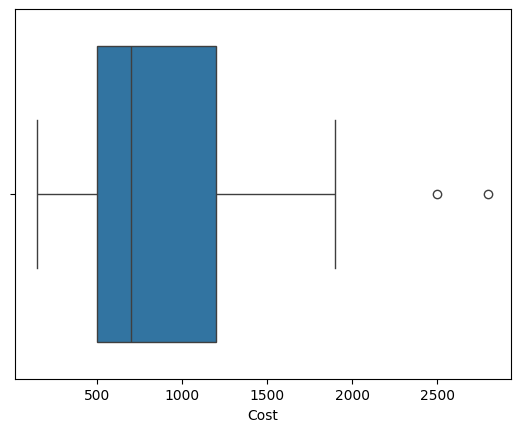

,Name,Cost
56,Feast - Sheraton Hyderabad Hotel,2500
92,Collage - Hyatt Hyderabad Gachibowli,2800


In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=restaurants["Cost"])

plt.show()

Q1 = restaurants["Cost"].quantile(0.25)
Q3 = restaurants["Cost"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

restaurants[restaurants["Cost"] > upper_bound][["Name", "Cost"]]

##### What all outlier treatment techniques have you used and why did you use those techniques?

Cost analysis revealed two high-cost restaurants: Feast - Sheraton Hyderabad Hotel (₹2500) and Collage - Hyatt Hyderabad Gachibowli (₹2800). These observations were retained because they correspond to genuine luxury dining establishments rather than anomalous data points. Their inclusion allows the clustering model to identify premium restaurant segments.

### 4. Feature Selection

In [46]:
cuisine_cols = [
    col for col in restaurant_eda.columns
    if col.startswith("Cuisine_")
]

print("Cuisine columns found:", len(cuisine_cols))

# Features for clustering
feature_cols = [
    "Cost",
    "Avg_Rating",
    "Avg_Sentiment",
    "Weighted_Sentiment"
] + cuisine_cols

print(feature_cols)

X = restaurant_eda[feature_cols].copy()

X = X.fillna(0)

print(X.shape)
X.head()

Cuisine columns found: 0
['Cost', 'Avg_Rating', 'Avg_Sentiment', 'Weighted_Sentiment']
(105, 4)


,Cost,Avg_Rating,Avg_Sentiment,Weighted_Sentiment
0,800,4.28,0.663394,0.638920
1,800,4.70,0.827125,0.802824
2,1300,4.66,0.790563,0.770101
3,800,3.21,0.288774,0.422792
4,1200,4.34,0.777797,0.786692


##### What all feature selection methods have you used  and why?

Feature engineering was used to create Average Rating, Average Sentiment, and Weighted Sentiment, while one-hot encoding was applied to convert cuisine categories into numerical features. Irrelevant attributes such as restaurant names, links, review text, and reviewer details were excluded to reduce noise and improve clustering performance.

##### Which all features you found important and why?

Cost, Average Rating, Average Sentiment, Weighted Sentiment, and Cuisine Indicators. Cost represents restaurant pricing, Average Rating reflects customer satisfaction, Average Sentiment captures opinions from review text, Weighted Sentiment accounts for reviewer influence, and Cuisine Indicators distinguish restaurants based on the type of food they offer

## ***7. ML Model Implementation***

### ML Model - 1

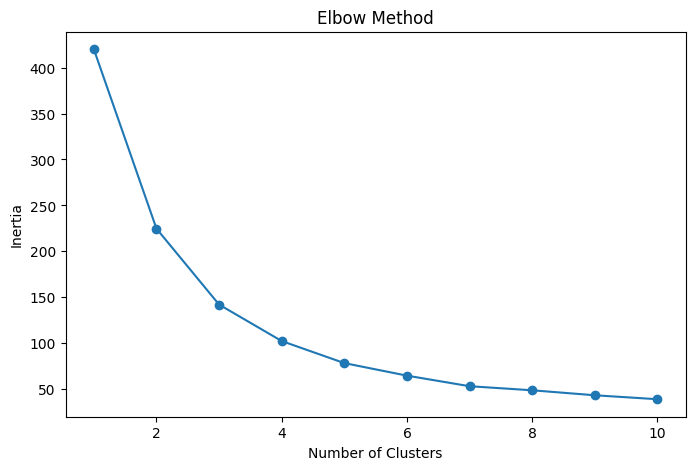

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()



In [48]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K={k}, Silhouette={score:.4f}")

    kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

restaurant_eda["Cluster"] = kmeans.fit_predict(
    X_scaled
)

from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    restaurant_eda["Cluster"]
)

print("Final Silhouette Score:", score)



K=2, Silhouette=0.4034
K=3, Silhouette=0.3999
K=4, Silhouette=0.3945
K=5, Silhouette=0.3692
K=6, Silhouette=0.3719
K=7, Silhouette=0.3794
K=8, Silhouette=0.3296
K=9, Silhouette=0.3243
K=10, Silhouette=0.3169
Final Silhouette Score: 0.3719079992939367


In [49]:
print(
    restaurant_eda["Cluster"]
    .value_counts()
)

cluster_summary = (
    restaurant_eda
    .groupby("Cluster")
    [
        [
            "Cost",
            "Avg_Rating",
            "Avg_Sentiment",
            "Weighted_Sentiment"
        ]
    ]
    .mean()
    .round(2)
)

print(cluster_summary)

Cluster
2    33
0    21
3    20
5    16
1    10
4     5
Name: count, dtype: int64
            Cost  Avg_Rating  Avg_Sentiment  Weighted_Sentiment
Cluster                                                        
0         623.81        3.85           0.61                0.67
1         455.00        2.88           0.05                0.09
2         554.55        3.38           0.33                0.45
3        1632.50        4.20           0.75                0.78
4         650.00         NaN            NaN                 NaN
5        1162.50        3.45           0.51                0.60


In [50]:
restaurant_eda.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Avg_Rating,Review_Count,Avg_Sentiment,Weighted_Sentiment,Cluster
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",4.28,100.0,0.663394,0.638920,0
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,4.70,100.0,0.827125,0.802824,0
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",4.66,100.0,0.790563,0.770101,3
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,3.21,100.0,0.288774,0.422792,2
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",4.34,100.0,0.777797,0.786692,3


In [51]:
restaurant_eda.to_csv("Final dataset.csv", index=False)

In [52]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=8,
    metric="euclidean",
    linkage="ward"
)

restaurant_eda["HC_Cluster"] = hc.fit_predict(X_scaled)

restaurant_eda[["Name", "HC_Cluster"]].head()

,Name,HC_Cluster
0,Beyond Flavours,7
1,Paradise,6
2,Flechazo,6
3,Shah Ghouse Hotel & Restaurant,4
4,Over The Moon Brew Company,6


In [53]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    restaurant_eda["HC_Cluster"]
)

print("Hierarchical Clustering Silhouette Score:", score)

Hierarchical Clustering Silhouette Score: 0.31056380332916234


In [54]:
print(
    restaurant_eda["HC_Cluster"]
    .value_counts()
    .sort_index()
)

HC_Cluster
0    16
1     7
2     5
3    18
4    20
5    18
6    13
7     8
Name: count, dtype: int64


In [55]:
cluster_summary = (
    restaurant_eda
    .groupby("HC_Cluster")
    [
        [
            "Cost",
            "Avg_Rating",
            "Avg_Sentiment",
            "Weighted_Sentiment"
        ]
    ]
    .mean()
    .round(2)
)

print(cluster_summary)

               Cost  Avg_Rating  Avg_Sentiment  Weighted_Sentiment
HC_Cluster                                                        
0            484.38        3.04           0.11                0.17
1           1957.14        3.80           0.63                0.72
2            650.00         NaN            NaN                 NaN
3            544.44        3.76           0.52                0.60
4            532.50        3.33           0.32                0.46
5           1116.67        3.42           0.50                0.60
6           1426.92        4.48           0.81                0.81
7            831.25        3.87           0.70                0.74


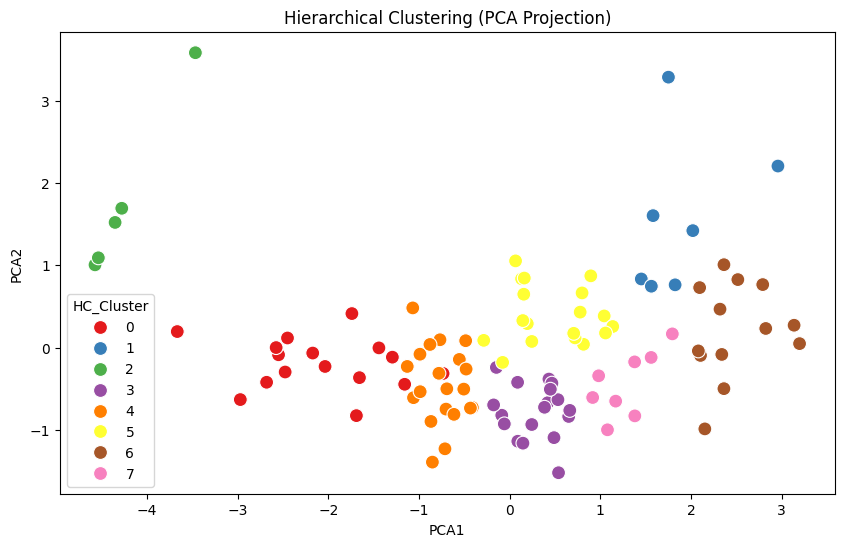

In [56]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

restaurant_eda["PCA1"] = pca_features[:,0]
restaurant_eda["PCA2"] = pca_features[:,1]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=restaurant_eda,
    x="PCA1",
    y="PCA2",
    hue="HC_Cluster",
    palette="Set1",
    s=100
)

plt.title("Hierarchical Clustering (PCA Projection)")
plt.show()

In [178]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in range(2, 11):

    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = hc.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K={k}, Silhouette={score:.4f}")

K=2, Silhouette=0.1581
K=3, Silhouette=0.1609
K=4, Silhouette=0.1519
K=5, Silhouette=0.1797
K=6, Silhouette=0.2177
K=7, Silhouette=0.2445
K=8, Silhouette=0.2452
K=9, Silhouette=0.2537
K=10, Silhouette=0.2643
